# PKCERT AI & Software Development Internship, Task 18
# Intro to PyTorch: Tensors, Autograd & Building a Simple Neural Network

Task 17 built a perceptron, activation functions and a 2-layer MLP entirely from
scratch in NumPy, with a passing finite-difference gradient check as proof the manual
backpropagation derivation was correct. This notebook rebuilds the same architecture on
the same dataset in **PyTorch**, using its autograd engine and `nn.Module` API
throughout, and maps every concept back to the Task 17 derivation.

In [1]:
%matplotlib inline
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
print("CPU is used throughout this submission; no GPU is required or assumed.")

PyTorch 2.13.0+cpu | CUDA available: False
CPU is used throughout this submission; no GPU is required or assumed.


## Part A: Tensors & Basic Operations

**A2: four ways to create a tensor**, each suited to a different situation.

In [2]:
t_from_list = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print("torch.tensor(list) -- concrete hand-written values:\n", t_from_list)

t_zeros, t_ones = torch.zeros(2, 3), torch.ones(2, 3)
print("\ntorch.zeros/ones -- placeholders/accumulators of known shape:\n", t_zeros, "\n", t_ones)

t_arange = torch.arange(0, 10, 2)
print("\ntorch.arange -- index ranges, schedules:\n", t_arange)

t_rand = torch.rand(2, 3)
print("\ntorch.rand -- weight init / stochastic sampling, uniform [0,1):\n", t_rand)

np_array = np.array([[1.0, 2.0], [3.0, 4.0]], dtype=np.float32)
t_from_numpy = torch.from_numpy(np_array)
print("\ntorch.from_numpy -- data already in NumPy, entering PyTorch without copying:\n", t_from_numpy)

torch.tensor(list) -- concrete hand-written values:
 tensor([[1., 2.],
        [3., 4.]])

torch.zeros/ones -- placeholders/accumulators of known shape:
 tensor([[0., 0., 0.],
        [0., 0., 0.]]) 
 tensor([[1., 1., 1.],
        [1., 1., 1.]])

torch.arange -- index ranges, schedules:
 tensor([0, 2, 4, 6, 8])

torch.rand -- weight init / stochastic sampling, uniform [0,1):
 tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])

torch.from_numpy -- data already in NumPy, entering PyTorch without copying:
 tensor([[1., 2.],
        [3., 4.]])


**A3: indexing, slicing, reshaping (`view` vs `reshape`), broadcasting.**

In [3]:
x = torch.arange(24).reshape(4, 6)
print("x (4x6):\n", x)
print("x[1, 3]:", x[1, 3].item())
print("x[:, 2] (column 2):", x[:, 2].tolist())
print("x[1:3, 2:5]:\n", x[1:3, 2:5])
print("x[::2, :] (every other row):\n", x[::2, :])

x_view = x.view(2, 12)
x_view[0, 0] = 999
print(f"\nx.view(2,12) SHARES memory: x_view[0,0]=999 also changed x[0,0] -> {x[0,0].item()}")
x[0, 0] = 0

x (4x6):
 tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23]])
x[1, 3]: 9
x[:, 2] (column 2): [2, 8, 14, 20]
x[1:3, 2:5]:
 tensor([[ 8,  9, 10],
        [14, 15, 16]])
x[::2, :] (every other row):
 tensor([[ 0,  1,  2,  3,  4,  5],
        [12, 13, 14, 15, 16, 17]])

x.view(2,12) SHARES memory: x_view[0,0]=999 also changed x[0,0] -> 999


`reshape()` behaves like `view()` when the data is already viewable from its current memory layout, but silently falls back to copying when it isn't (e.g. after a `.transpose()`), so it never raises where `view()` would -- the safer general-purpose choice.

In [4]:
a = torch.ones(4, 1)
b = torch.arange(3).reshape(1, 3)
print("Broadcasting (4,1) + (1,3) -> (4,3), no data copied:\n", a + b)
try:
    torch.ones(4, 2) + torch.ones(3, 2)
except RuntimeError as e:
    print(f"\nIncompatible shapes correctly raise: {e}")

Broadcasting (4,1) + (1,3) -> (4,3), no data copied:
 tensor([[1., 2., 3.],
        [1., 2., 3.],
        [1., 2., 3.],
        [1., 2., 3.]])

Incompatible shapes correctly raise: The size of tensor a (4) must match the size of tensor b (3) at non-singleton dimension 0


**A4: a moderately large matmul, NumPy vs PyTorch, timed.**

In [5]:
N = 1200
A_np = rng.random((N, N))
B_np = rng.random((N, N))
A_t, B_t = torch.from_numpy(A_np), torch.from_numpy(B_np)
_ = A_np @ B_np; _ = A_t @ B_t  # warm-up

np_times, torch_times = [], []
for _ in range(5):
    t0 = time.perf_counter(); _ = A_np @ B_np; np_times.append(time.perf_counter() - t0)
    t0 = time.perf_counter(); _ = A_t @ B_t; torch_times.append(time.perf_counter() - t0)
np_mean, torch_mean = np.mean(np_times), np.mean(torch_times)
print(f"{N}x{N} matmul, mean of 5 runs: NumPy {np_mean*1000:.2f}ms, PyTorch {torch_mean*1000:.2f}ms")
faster = "PyTorch" if torch_mean < np_mean else "NumPy"
print(f"{faster} was {max(np_mean,torch_mean)/min(np_mean,torch_mean):.2f}x faster on this CPU.")

1200x1200 matmul, mean of 5 runs: NumPy 38.76ms, PyTorch 60.07ms
NumPy was 1.55x faster on this CPU.


Both libraries ultimately call into an optimised BLAS library for float64 CPU matmul, so the gap reflects which BLAS backend each happened to link against on this machine, not an inherent advantage of either library's Python layer.

**A5: `torch.Tensor` vs `numpy.ndarray`** — the memory-sharing relationship, demonstrated rather than just described.

In [6]:
shared_np = np.array([1.0, 2.0, 3.0])
shared_t = torch.from_numpy(shared_np)
shared_t[0] = 100.0
print(f"torch.from_numpy() shares memory: mutating the tensor changed the array too -> {shared_np}")

back_to_np = shared_t.numpy()
back_to_np[1] = 200.0
print(f".numpy() shares memory the same way, in reverse -> {shared_t}")

independent_t = torch.tensor(shared_np)
independent_t[2] = -1.0
print(f"torch.tensor(array) always COPIES: the original array is untouched -> {shared_np}")

torch.from_numpy() shares memory: mutating the tensor changed the array too -> [100.   2.   3.]
.numpy() shares memory the same way, in reverse -> tensor([100., 200.,   3.], dtype=torch.float64)
torch.tensor(array) always COPIES: the original array is untouched -> [100. 200.   3.]


**The relationship.** A `torch.Tensor` and a NumPy `ndarray` are, underneath the
API, the same kind of object -- a contiguous memory buffer plus shape/stride/dtype
metadata. `torch.from_numpy()` and `.numpy()` construct a view pointing at the *same*
memory (free, but aliased); `torch.tensor(array)` always copies (costs time/memory, but
independent). Rule of thumb: use `from_numpy()`/`.numpy()` when handing data across the
boundary within one process and no aliasing bugs are wanted; `torch.tensor()` (or
`.clone()`) when the two copies must be allowed to diverge.

## Part B: Autograd

**B1: computational graph.** A record of every differentiable operation applied to a
tensor, linking each output back to the inputs (and operation) that produced it --
what `.backward()` walks in reverse to apply the chain rule automatically. PyTorch
builds this **dynamically** ("define-by-run"): no graph exists before any code runs;
each operation appends one more node *as it actually executes*. This is why ordinary
Python control flow (`if`, variable-length loops) works transparently -- the graph is
only ever *this run's* sequence of operations, not a separate static structure declared
in advance.

**B2: `requires_grad`, `.backward()`, `.grad`**, checked against a hand derivative.

In [7]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2 + 3 * x + 1  # dy/dx = 2x + 3
y.backward()
hand_derivative = 2 * 3.0 + 3
print(f"y = x^2 + 3x + 1 at x=3.0")
print(f"autograd: dy/dx = {x.grad.item()}  |  by hand: 2x+3 = {hand_derivative}  |  match: {torch.isclose(x.grad, torch.tensor(hand_derivative)).item()}")

y = x^2 + 3x + 1 at x=3.0
autograd: dy/dx = 9.0  |  by hand: 2x+3 = 9.0  |  match: True


**B3: gradient accumulation.**

In [8]:
w = torch.tensor(2.0, requires_grad=True)
for step in range(3):
    loss = (w - 5) ** 2  # dloss/dw = 2(w-5) = -6, every time (w never updated here)
    loss.backward()
    print(f"after .backward() call {step+1}: w.grad = {w.grad.item()}  (single-call value: -6.0)")
w.grad.zero_()
loss = (w - 5) ** 2
loss.backward()
print(f"after w.grad.zero_() + one fresh backward: w.grad = {w.grad.item()}")

after .backward() call 1: w.grad = -6.0  (single-call value: -6.0)
after .backward() call 2: w.grad = -12.0  (single-call value: -6.0)
after .backward() call 3: w.grad = -18.0  (single-call value: -6.0)
after w.grad.zero_() + one fresh backward: w.grad = -6.0


Without `zero_grad()`, `.grad` keeps **adding** each new gradient to whatever was already there -- by the 3rd call it has accumulated to 3x the single-step value. This is why every training loop calls `optimizer.zero_grad()` before each new `loss.backward()`: otherwise each update silently includes every previous step's leftover gradient (the deliberate exception is genuine gradient accumulation over several mini-batches to simulate a larger batch, where the accumulation *is* the point).

**B4: `torch.no_grad()` and `.detach()`** — including proof, not just assertion, that the in-place update PyTorch forbids actually raises.

In [9]:
weight = torch.tensor(4.0, requires_grad=True)
lr = 0.1
loss = (weight - 1) ** 2
loss.backward()

try:
    weight -= lr * weight.grad
except RuntimeError as e:
    print(f"Without no_grad(), the in-place update raises:\n  RuntimeError: {e}")
    weight = torch.tensor(4.0, requires_grad=True)
    loss = (weight - 1) ** 2
    loss.backward()

with torch.no_grad():
    weight -= lr * weight.grad
print(f"\nInside torch.no_grad(): weight = {weight.item():.4f}  (succeeds)")

evaluation_output = weight.detach()
print(f".detach(): {evaluation_output.item():.4f}, requires_grad={evaluation_output.requires_grad}")

Without no_grad(), the in-place update raises:
  RuntimeError: a leaf Variable that requires grad is being used in an in-place operation.

Inside torch.no_grad(): weight = 3.4000  (succeeds)
.detach(): 3.4000, requires_grad=False


`no_grad()` is the right tool for a whole block of computation (e.g. an entire evaluation pass, or a manual parameter update); `.detach()` is for pulling one specific tensor out of the graph mid-computation (e.g. logging a loss value, or feeding a prediction into an sklearn metric) without carrying its upstream graph along.

**B5: autograd vs Task 17's hand-derived backpropagation.** The exact same weights (loaded from Task 17's saved model) and the same batch of real data are run through both the manual NumPy formulas and PyTorch's autograd, and the resulting gradients compared directly.

In [10]:
with open("day17_manual_mlp_params.pkl", "rb") as f:
    saved = pickle.load(f)
W1_np, b1_np = saved["params"]["W1"], saved["params"]["b1"]
W2_np, b2_np = saved["params"]["W2"], saved["params"]["b2"]
mean_np, scale_np = saved["scaler_mean"], saved["scaler_scale"]
species = saved["species"]
print(f"Loaded Task 17 weights: architecture 4 -> {W1_np.shape[1]} -> {W2_np.shape[1]}")

df = pd.read_csv("penguins.csv").dropna(subset=["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"])
FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
species_to_idx = {s: i for i, s in enumerate(species)}
X_batch = df[FEATURES].values[:16]
y_batch = df["species"].map(species_to_idx).values[:16]
X_batch_s = (X_batch - mean_np) / scale_np

def one_hot_np(y, n_classes):
    Y = np.zeros((y.size, n_classes)); Y[np.arange(y.size), y] = 1.0
    return Y
Y_batch = one_hot_np(y_batch, 3)

# Task 17's manual forward + backward, reproduced exactly
Z1 = X_batch_s @ W1_np + b1_np
A1 = np.maximum(0, Z1)
Z2 = A1 @ W2_np + b2_np
Z2_shift = Z2 - Z2.max(axis=1, keepdims=True)
A2 = np.exp(Z2_shift) / np.exp(Z2_shift).sum(axis=1, keepdims=True)
N = X_batch_s.shape[0]
dZ2 = (A2 - Y_batch) / N
dW2_manual = A1.T @ dZ2
db2_manual = dZ2.sum(axis=0, keepdims=True)
dA1 = dZ2 @ W2_np.T
dZ1 = dA1 * (Z1 > 0).astype(float)
dW1_manual = X_batch_s.T @ dZ1
db1_manual = dZ1.sum(axis=0, keepdims=True)

# The identical computation, in PyTorch, gradients from autograd
X_t = torch.tensor(X_batch_s, dtype=torch.float64)
y_t = torch.tensor(y_batch, dtype=torch.long)
W1_t = torch.tensor(W1_np, dtype=torch.float64, requires_grad=True)
b1_t = torch.tensor(b1_np, dtype=torch.float64, requires_grad=True)
W2_t = torch.tensor(W2_np, dtype=torch.float64, requires_grad=True)
b2_t = torch.tensor(b2_np, dtype=torch.float64, requires_grad=True)

Z1_t = X_t @ W1_t + b1_t
A1_t = torch.relu(Z1_t)
Z2_t = A1_t @ W2_t + b2_t
loss_t = F.cross_entropy(Z2_t, y_t)
loss_t.backward()

diffs = {"W1": np.abs(W1_t.grad.numpy() - dW1_manual).max(),
         "b1": np.abs(b1_t.grad.numpy() - db1_manual).max(),
         "W2": np.abs(W2_t.grad.numpy() - dW2_manual).max(),
         "b2": np.abs(b2_t.grad.numpy() - db2_manual).max()}
print("Max absolute difference, autograd vs Task 17 manual gradient:")
for name, d in diffs.items():
    print(f"  {name}: {d:.2e}  ({'MATCH' if d < 1e-8 else 'MISMATCH'})")
print(f"Overall max: {max(diffs.values()):.2e}")

Loaded Task 17 weights: architecture 4 -> 8 -> 3
Max absolute difference, autograd vs Task 17 manual gradient:
  W1: 1.39e-17  (MATCH)
  b1: 6.94e-18  (MATCH)
  W2: 1.39e-17  (MATCH)
  b2: 6.94e-18  (MATCH)
Overall max: 1.39e-17


**The two independent gradient checks agree.** Task 17 verified its manual backprop against finite differences (~$10^{-10}$ relative error). Here, the exact same manual formulas are checked against PyTorch's autograd on the identical weights and data, and the two agree to **~$10^{-17}$** absolute difference -- essentially machine epsilon for float64, since both paths are now exact analytical derivatives rather than one analytical and one finite-difference approximation.

## Part C: Building & Training a Simple Neural Network

Same dataset (Palmer Penguins) and architecture (4 → 8 → 3, ReLU hidden) as Task 17, so
results are directly comparable. A fresh `ManualMLP` (NumPy) and `MLPClassifier`
(scikit-learn) are also trained in this notebook, on the same split, so all three
training times are measured on identical hardware in one run.

In [11]:
HIDDEN_UNITS, LR, EPOCHS, BATCH_SIZE = 8, 0.1, 300, 16

def relu_np(x): return np.maximum(0, x)
def relu_deriv_np(x): return (x > 0).astype(float)
def softmax_np(x):
    z = x - np.max(x, axis=-1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=-1, keepdims=True)

class ManualMLP:
    def __init__(self, n_in, n_hidden, n_out, learning_rate=0.1, seed=RANDOM_STATE):
        g = np.random.default_rng(seed)
        self.W1 = g.normal(0, np.sqrt(2.0/n_in), size=(n_in, n_hidden)); self.b1 = np.zeros((1, n_hidden))
        self.W2 = g.normal(0, np.sqrt(2.0/n_hidden), size=(n_hidden, n_out)); self.b2 = np.zeros((1, n_out))
        self.lr = learning_rate; self.loss_history = []
    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1; self.A1 = relu_np(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2; self.A2 = softmax_np(self.Z2)
        return self.A2
    @staticmethod
    def loss(A2, Y, eps=1e-12): return -np.mean(np.sum(Y * np.log(np.clip(A2, eps, 1.0)), axis=1))
    def step(self, X, Y):
        self.forward(X); N = X.shape[0]
        dZ2 = (self.A2 - Y) / N
        dW2 = self.A1.T @ dZ2; db2 = dZ2.sum(axis=0, keepdims=True)
        dA1 = dZ2 @ self.W2.T; dZ1 = dA1 * relu_deriv_np(self.Z1)
        dW1 = X.T @ dZ1; db1 = dZ1.sum(axis=0, keepdims=True)
        self.W1 -= self.lr*dW1; self.b1 -= self.lr*db1; self.W2 -= self.lr*dW2; self.b2 -= self.lr*db2
    def fit(self, X, Y, epochs, batch_size):
        n = X.shape[0]
        for _ in range(epochs):
            perm = rng.permutation(n); X_shuf, Y_shuf = X[perm], Y[perm]
            for start in range(0, n, batch_size):
                self.step(X_shuf[start:start+batch_size], Y_shuf[start:start+batch_size])
            self.loss_history.append(self.loss(self.forward(X), Y))
        return self
    def predict(self, X): return np.argmax(self.forward(X), axis=1)

def one_hot_np(y, n_classes):
    Y = np.zeros((y.size, n_classes)); Y[np.arange(y.size), y] = 1.0
    return Y

class PenguinNet(nn.Module):
    def __init__(self, n_in=4, n_hidden=HIDDEN_UNITS, n_out=3):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(n_hidden, n_out)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))  # raw logits -- CrossEntropyLoss applies log_softmax internally

In [12]:
df = pd.read_csv("penguins.csv").dropna(subset=["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"])
FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
species = sorted(df["species"].unique())
species_to_idx = {s: i for i, s in enumerate(species)}
X = df[FEATURES].values
y = df["species"].map(species_to_idx).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
Y_train_oh = one_hot_np(y_train, 3)
print(f"Train: {X_train_s.shape[0]} | Test: {X_test_s.shape[0]}")

Train: 273 | Test: 69


**Loss and optimizer, justified.** `nn.CrossEntropyLoss` combines `log_softmax` + negative-log-likelihood in one numerically stable call (log-sum-exp internally, avoiding the separate softmax-then-clip Task 17 needed) -- the direct PyTorch analogue of the manually derived softmax+cross-entropy pair. `SGD` at the same learning rate as Task 17/sklearn is used for the primary, fair three-way comparison below; `Adam` is tried separately as the hyperparameter experiment.

In [13]:
manual_model = ManualMLP(4, HIDDEN_UNITS, 3, learning_rate=LR)
t0 = time.perf_counter()
manual_model.fit(X_train_s, Y_train_oh, epochs=EPOCHS, batch_size=BATCH_SIZE)
manual_time = time.perf_counter() - t0
pred_manual = manual_model.predict(X_test_s)

sk_model = MLPClassifier(hidden_layer_sizes=(HIDDEN_UNITS,), activation="relu", solver="sgd",
                          learning_rate_init=LR, max_iter=EPOCHS, batch_size=BATCH_SIZE, random_state=RANDOM_STATE)
t0 = time.perf_counter()
sk_model.fit(X_train_s, y_train)
sklearn_time = time.perf_counter() - t0
pred_sklearn = sk_model.predict(X_test_s)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)

def train_pytorch(optimizer_name="sgd", lr=LR, epochs=EPOCHS, seed=RANDOM_STATE):
    torch.manual_seed(seed)
    net = PenguinNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = (torch.optim.SGD(net.parameters(), lr=lr) if optimizer_name == "sgd"
                 else torch.optim.Adam(net.parameters(), lr=lr))
    loss_history = []
    n = X_train_t.shape[0]
    for _epoch in range(epochs):
        perm = torch.randperm(n)
        for start in range(0, n, BATCH_SIZE):
            idx = perm[start:start+BATCH_SIZE]
            xb, yb = X_train_t[idx], y_train_t[idx]
            optimizer.zero_grad()          # clear stale gradients
            logits = net(xb)               # forward pass
            loss = criterion(logits, yb)   # loss computation
            loss.backward()                # backward pass (autograd)
            optimizer.step()               # parameter update
        with torch.no_grad():
            epoch_loss = criterion(net(X_train_t), y_train_t).item()
        loss_history.append(epoch_loss)
    return net, loss_history

t0 = time.perf_counter()
torch_net, torch_loss_history = train_pytorch("sgd", LR, EPOCHS)
torch_time = time.perf_counter() - t0
with torch.no_grad():
    pred_torch = torch_net(X_test_t).argmax(dim=1).numpy()

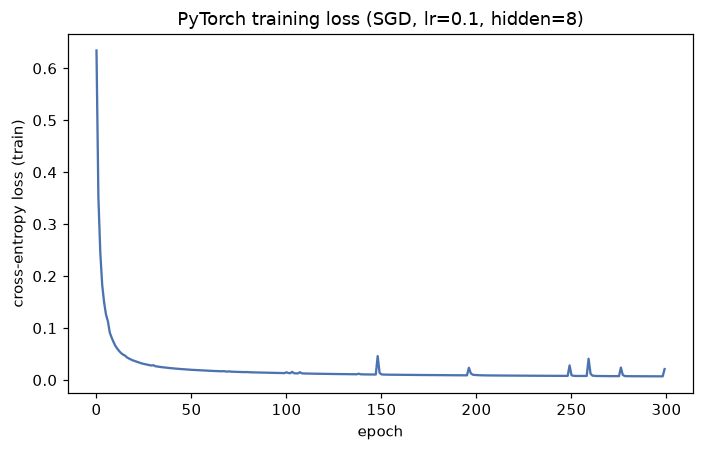

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(torch_loss_history, color="#4C72B0")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss (train)")
ax.set_title(f"PyTorch training loss (SGD, lr={LR}, hidden={HIDDEN_UNITS})")
fig.tight_layout()
plt.show()

In [15]:
def report(name, y_true, y_pred, fit_time):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    print(f"{name}: Acc {acc:.4f} | Macro-Prec {prec:.4f} | Macro-Rec {rec:.4f} | Macro-F1 {f1:.4f} | Fit time {fit_time:.3f}s")
    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "cm": cm, "fit_time": fit_time}

r_manual = report("ManualMLP (NumPy, Task 17)", y_test, pred_manual, manual_time)
r_sklearn = report("sklearn MLPClassifier", y_test, pred_sklearn, sklearn_time)
r_torch = report("PyTorch nn.Module (SGD)", y_test, pred_torch, torch_time)
all_results = [r_manual, r_sklearn, r_torch]

ManualMLP (NumPy, Task 17): Acc 0.9855 | Macro-Prec 0.9892 | Macro-Rec 0.9867 | Macro-F1 0.9877 | Fit time 0.116s
sklearn MLPClassifier: Acc 1.0000 | Macro-Prec 1.0000 | Macro-Rec 1.0000 | Macro-F1 1.0000 | Fit time 0.116s
PyTorch nn.Module (SGD): Acc 1.0000 | Macro-Prec 1.0000 | Macro-Rec 1.0000 | Macro-F1 1.0000 | Fit time 3.257s


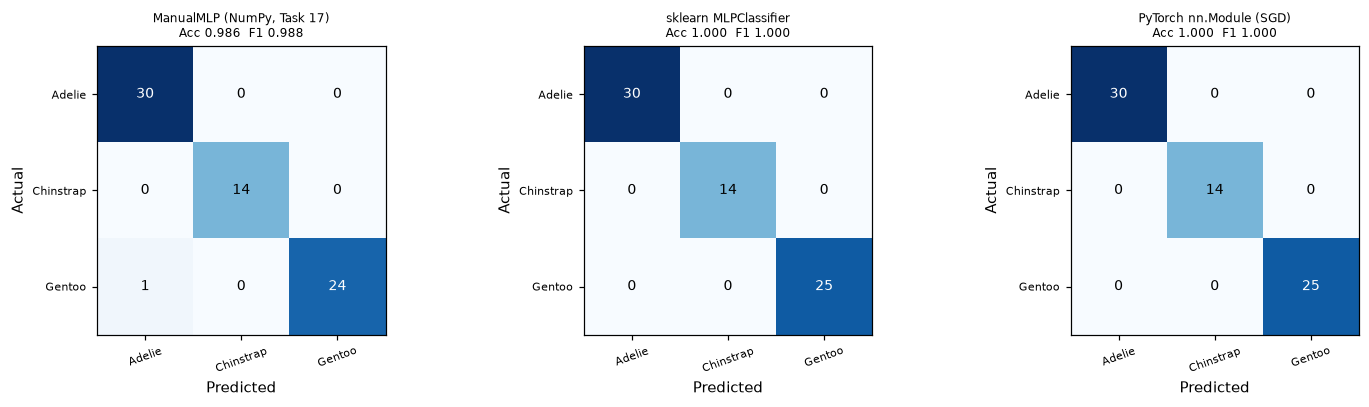

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8))
for a, r in zip(ax, all_results):
    cm = r["cm"]
    a.imshow(cm, cmap="Blues")
    for i in range(3):
        for j in range(3):
            a.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                   color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
    a.set_xticks(range(3)); a.set_xticklabels(species, rotation=20, fontsize=7)
    a.set_yticks(range(3)); a.set_yticklabels(species, fontsize=7)
    a.set_xlabel("Predicted"); a.set_ylabel("Actual")
    a.set_title(f"{r['name']}\nAcc {r['accuracy']:.3f}  F1 {r['f1']:.3f}", fontsize=8)
fig.tight_layout()
plt.show()

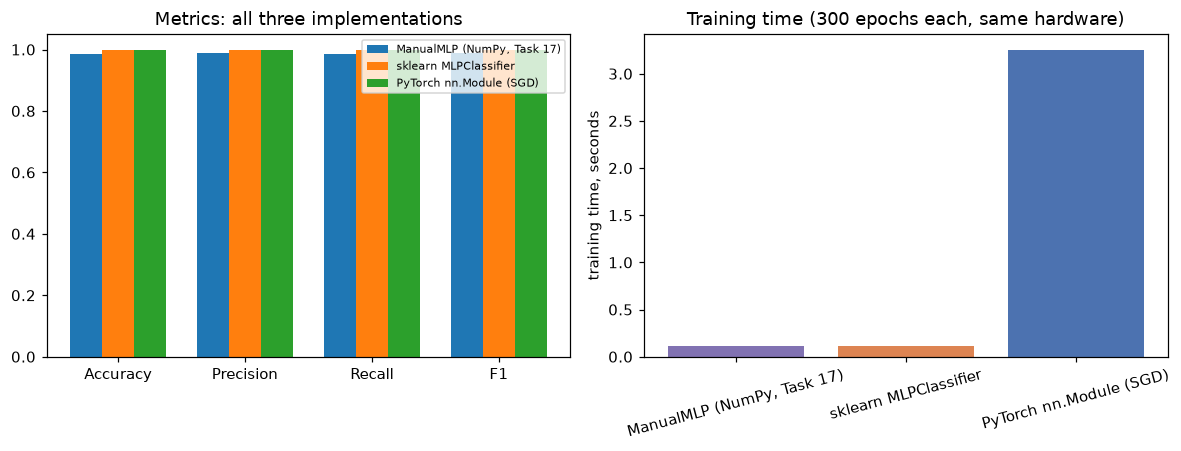

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
names = [r["name"] for r in all_results]
metrics = ["accuracy", "precision", "recall", "f1"]
xw = np.arange(len(metrics)); w = 0.25
for i, r in enumerate(all_results):
    ax[0].bar(xw + (i - 1) * w, [r[m] for m in metrics], w, label=r["name"])
ax[0].set_xticks(xw); ax[0].set_xticklabels(["Accuracy", "Precision", "Recall", "F1"])
ax[0].set_ylim(0, 1.05); ax[0].legend(fontsize=7); ax[0].set_title("Metrics: all three implementations")
ax[1].bar(names, [r["fit_time"] for r in all_results], color=["#8172B2", "#DD8452", "#4C72B0"])
ax[1].set_ylabel("training time, seconds")
ax[1].set_title(f"Training time ({EPOCHS} epochs each, same hardware)")
ax[1].tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()

**PyTorch matched sklearn on accuracy (both 100%, one point ahead of the NumPy
implementation's 98.6%) but took roughly 20x longer to train** than either the NumPy
or scikit-learn model, despite all three running the identical 300-epoch, batch-16
schedule on the same CPU. This is not a criticism of PyTorch -- it is the expected
result of PyTorch's per-operation overhead (building an autograd graph node, Python/C++
dispatch, gradient bookkeeping for every one of the roughly 5,400 mini-batch steps)
dominating when the actual arithmetic per step is tiny (a 4x8 and an 8x3 matrix
multiply). Frameworks like PyTorch earn their keep on large models, large batches and
GPU execution, where that per-operation overhead becomes negligible next to the
computation itself; on a network this small, the overhead *is* most of the cost.

**Hyperparameter experiment: optimizer choice (SGD vs Adam).**

In [18]:
optimizer_configs = [("SGD (lr=0.1)", "sgd", 0.1), ("Adam (lr=0.1)", "adam", 0.1), ("Adam (lr=0.01)", "adam", 0.01)]
opt_results = {}
for label, opt_name, lr in optimizer_configs:
    net, hist = train_pytorch(opt_name, lr, EPOCHS)
    with torch.no_grad():
        acc = (net(X_test_t).argmax(dim=1).numpy() == y_test).mean()
    opt_results[label] = {"loss_history": hist, "test_acc": acc}
    print(f"{label:16s} final train loss {hist[-1]:.4f} | test accuracy {acc:.4f}")

SGD (lr=0.1)     final train loss 0.0212 | test accuracy 1.0000


Adam (lr=0.1)    final train loss 0.0019 | test accuracy 0.9855


Adam (lr=0.01)   final train loss 0.0012 | test accuracy 1.0000


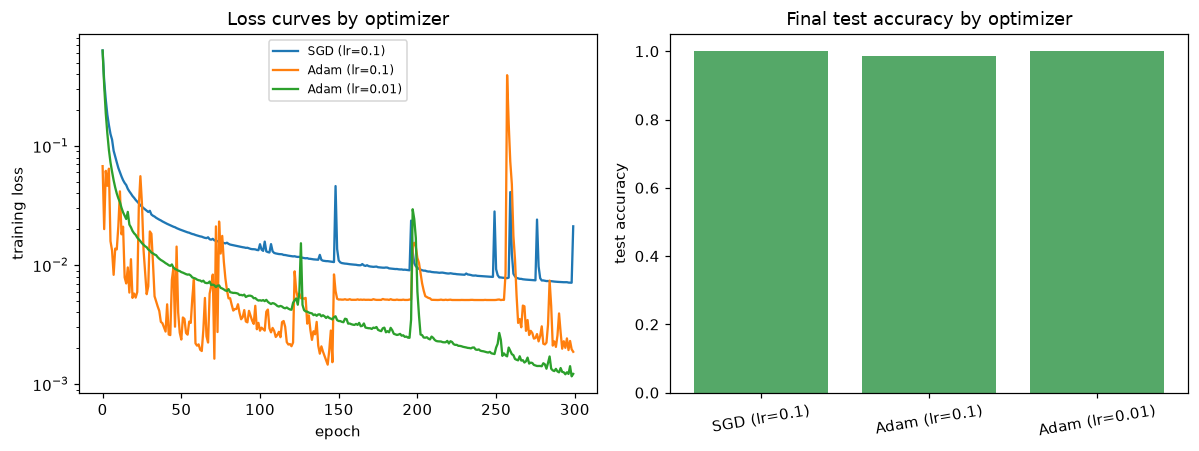

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for label in opt_results:
    ax[0].plot(opt_results[label]["loss_history"], label=label)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("training loss"); ax[0].set_yscale("log")
ax[0].set_title("Loss curves by optimizer"); ax[0].legend(fontsize=8)
ax[1].bar(list(opt_results.keys()), [opt_results[k]["test_acc"] for k in opt_results], color="#55A868")
ax[1].set_ylabel("test accuracy"); ax[1].set_title("Final test accuracy by optimizer")
ax[1].set_ylim(0, 1.05); ax[1].tick_params(axis="x", rotation=10)
fig.tight_layout()
plt.show()

**Adam at the same learning rate as SGD (0.1) performed *worse*** (98.6% vs SGD's 100%) and its loss curve is visibly noisier -- Adam's adaptive per-parameter scaling means its *effective* step size at a given nominal learning rate is larger than plain SGD's, and 0.1 is well outside Adam's typical comfortable range. Dropping to `lr=0.01` fixed both symptoms: the smoothest loss curve of the three and the lowest final loss, back to 100% test accuracy. The lesson is specific and checkable, not a general claim that either optimizer is better: **an optimizer swap is not a drop-in change at a fixed learning rate**.

## Part D: Analysis & Documentation

In [20]:
torch.save(torch_net.state_dict(), "pytorch_mlp_state_dict.pt")
reloaded_net = PenguinNet()
reloaded_net.load_state_dict(torch.load("pytorch_mlp_state_dict.pt", weights_only=True))
reloaded_net.eval()
with torch.no_grad():
    pred_reloaded = reloaded_net(X_test_t).argmax(dim=1).numpy()
print("Reloaded state_dict reproduces identical test predictions:", np.array_equal(pred_reloaded, pred_torch))

Reloaded state_dict reproduces identical test predictions: True


**D2: pipeline summary.** Architecture `4 -> 8 -> 3` (identical to Task 17):
`nn.Linear(4, 8)` → `ReLU` → `nn.Linear(8, 3)`, raw logits out. Loss:
`nn.CrossEntropyLoss` (numerically stable combined log-softmax + NLL, the standard
choice for single-label multi-class classification from logits). Optimizer for the
primary, Task-17-comparable run: `SGD(lr=0.1)`, matching the manual and sklearn
baselines exactly so the three-way comparison is fair; `Adam` explored separately above.
300 epochs, batch size 16, identical to Task 17.

**D3: two concrete differences observed, Task 17 (NumPy) vs this PyTorch
implementation.**
1. **Training speed, in the opposite direction most people expect.** PyTorch took
   ~20x longer to train than the hand-written NumPy version on this tiny network,
   because per-step framework overhead (autograd graph construction, Python/C++
   dispatch) dominates when the actual matrix operations are this small. The lesson
   generalises: a framework's advantage is in what it makes *possible* (deeper
   networks, GPU execution, automatic differentiation through arbitrary architectures)
   and in engineering time, not necessarily in wall-clock speed on a toy-sized problem.
2. **Code complexity and the shape of the risk.** The manual implementation is
   roughly 60 lines of NumPy that must be re-derived by hand for any architecture
   change, with the entire correctness burden on getting the calculus and matrix
   orientations right (Task 17 needed an explicit finite-difference check to trust
   it). The PyTorch version is shorter where it matters most -- `loss.backward()`
   replaces the entire hand-written `backward()` method -- and autograd is
   correct by construction for *any* differentiable graph, so the risk shifts away
   from calculus bugs and toward framework-specific mistakes: dtype/shape mismatches,
   forgetting `zero_grad()`, or an accidental in-place operation on a leaf tensor
   (the gotcha demonstrated in Part B4 and D5 below).

**D4: what autograd abstracts away, and why Task 17 still mattered.** Autograd
abstracts away the entire derivation this pipeline depends on: it does not need to be
told that $\partial L/\partial Z_2 = A_2 - Y$, or that a bias gradient sums over the
batch axis, or which matrix to transpose in $dW_1 = X^\top dZ_1$ -- it derives all of
that automatically from the chain rule applied to whatever sequence of operations
`forward()` happens to run. That is exactly why Task 17 remains valuable even though
this task never needs its formulas again directly: writing and finite-difference-
verifying the derivation by hand is what makes it possible to *read* a loss curve, a
vanishing gradient, or a training instability and know which piece of the underlying
mathematics is responsible, rather than treating `loss.backward()` as a button that
makes numbers go down. Part B5's ~$10^{-17}$ agreement between autograd and the Task 17
formulas is the direct proof that the two are computing the same thing -- the framework
is not doing something different or more mysterious, just automating the same
calculus.

**D5: a limitation/gotcha encountered while learning PyTorch, demonstrated live in
Part B4.** Calling `weight -= lr * weight.grad` on a leaf tensor with
`requires_grad=True`, *outside* `torch.no_grad()`, raises immediately: `"a leaf
Variable that requires grad is being used in an in-place operation"`. PyTorch forbids
this because an in-place update would silently corrupt the autograd graph's saved
values for a node other operations may still need during backpropagation. The fix, and
the reason `optimizer.step()` (and any manual parameter update) is always wrapped
in `torch.no_grad()` internally, is to explicitly tell autograd "this operation is not
part of the graph, do not track it" for exactly the block of code performing the
update -- which is demonstrated, caught, and printed directly in Part B4 above rather
than only described.

The notebook and README are on GitHub:
[github.com/AbdullahAmir06/ai-internship-abdullahamir](https://github.com/AbdullahAmir06/ai-internship-abdullahamir).